In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("heart.csv")   
print("Dataset loaded successfully!")


Dataset loaded successfully!


In [18]:
print(df.head())

   age     sex              cp  trestbps   chol    fbs         restecg  \
0   63    Male  typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male    asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male    asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male     non-anginal     130.0  250.0  False          normal   
4   41  Female  typical angina     130.0  204.0  False  lv hypertrophy   

   thalch  exang  oldpeak  num  
0   150.0  False      2.3    0  
1   108.0   True      1.5    2  
2   129.0   True      2.6    1  
3   187.0  False      3.5    0  
4   172.0  False      1.4    0  


In [19]:
print(df.shape)
print(df.info())
print(df.describe())

(918, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   cp        918 non-null    object 
 3   trestbps  918 non-null    float64
 4   chol      918 non-null    float64
 5   fbs       918 non-null    bool   
 6   restecg   918 non-null    object 
 7   thalch    918 non-null    float64
 8   exang     918 non-null    bool   
 9   oldpeak   918 non-null    float64
 10  num       918 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 66.5+ KB
None
              age    trestbps        chol      thalch    oldpeak         num
count  918.000000  918.000000  918.000000  918.000000  918.00000  918.000000
mean    53.510893  132.141612  199.862745  137.689542    0.85512    0.995643
std      9.432617   17.924706  109.154522   25.153455    1.05845    1.

In [20]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64


In [21]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


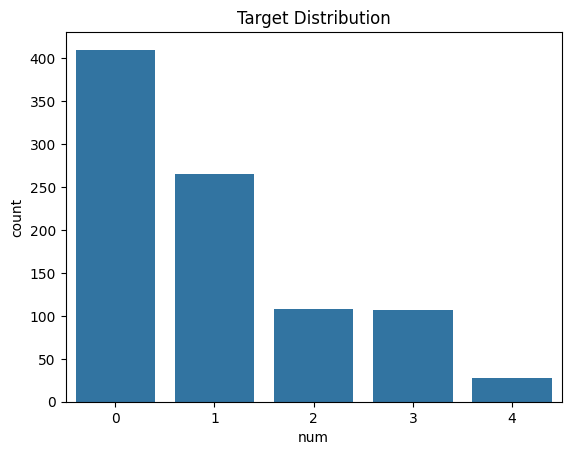

num
0    410
1    265
2    108
3    107
4     28
Name: count, dtype: int64


In [22]:
sns.countplot(x=df["num"])   
plt.title("Target Distribution")
plt.show()

print(df["num"].value_counts())

In [23]:
df["target"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

In [24]:
df["target"].value_counts()

target
1    508
0    410
Name: count, dtype: int64

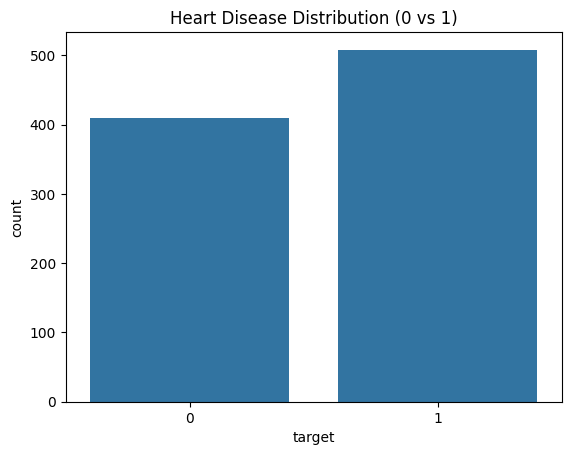

target
1    508
0    410
Name: count, dtype: int64


In [25]:
sns.countplot(x=df["target"])
plt.title("Heart Disease Distribution (0 vs 1)")
plt.show()

print(df["target"].value_counts())

In [28]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]
cat_cols = ["sex", "cp", "fbs", "restecg", "exang"]

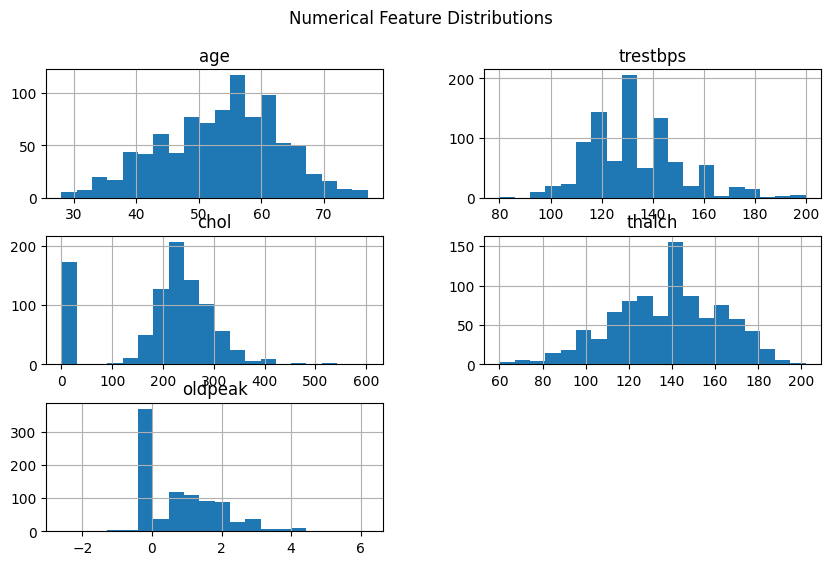

In [29]:
df[num_cols].hist(figsize=(10,6), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

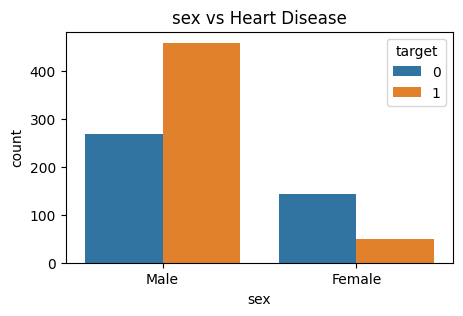

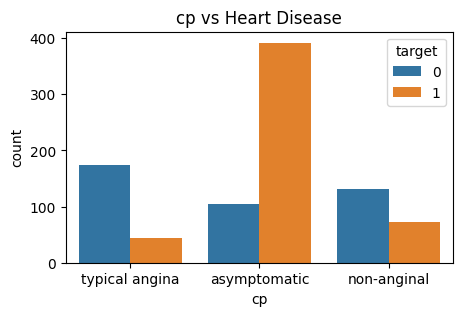

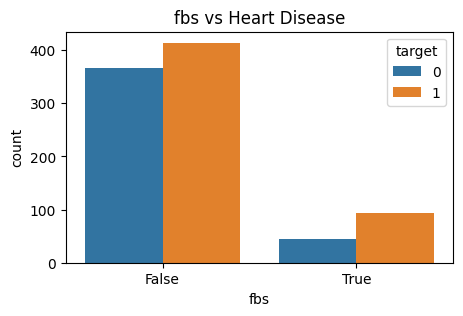

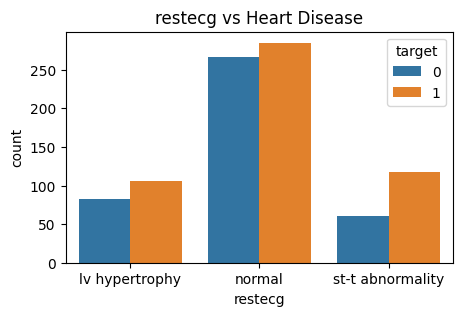

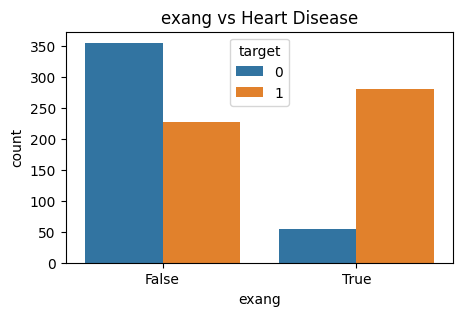

In [30]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col], hue=df["target"])
    plt.title(f"{col} vs Heart Disease")
    plt.show()

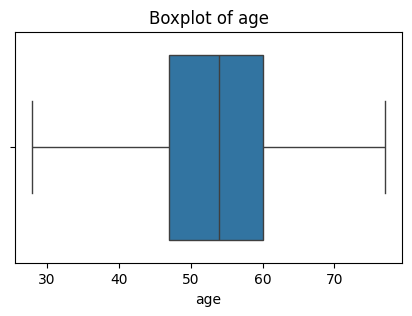

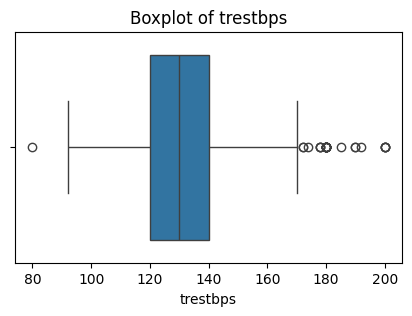

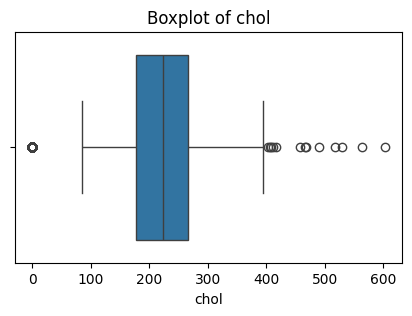

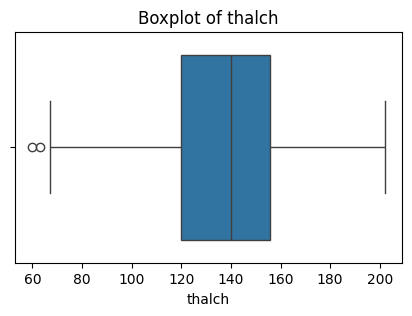

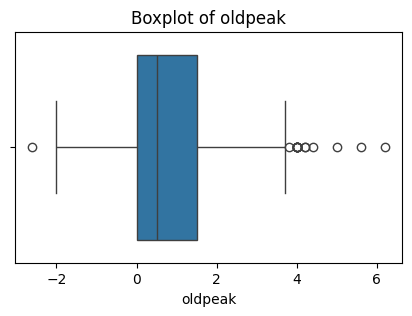

In [32]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [33]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

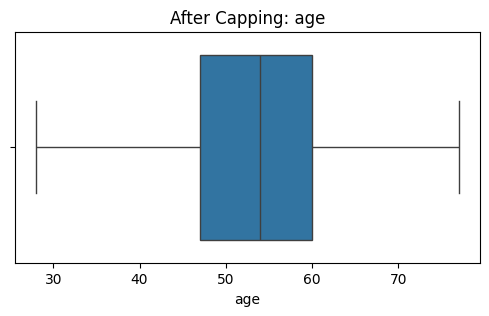

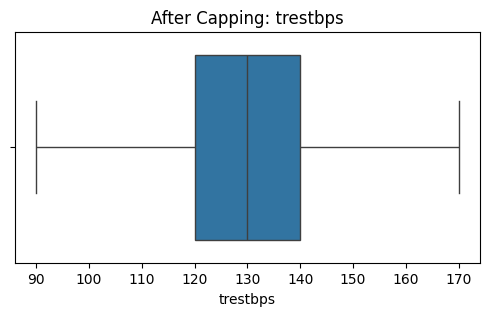

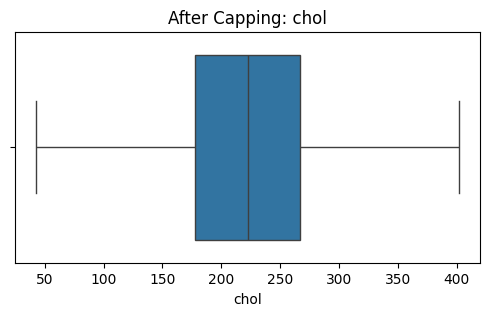

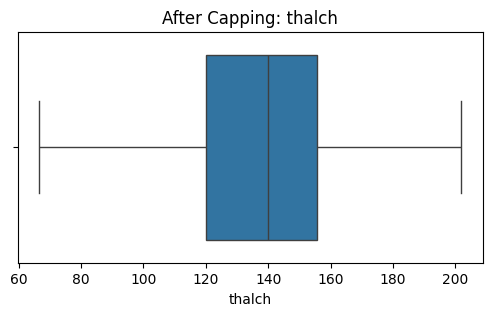

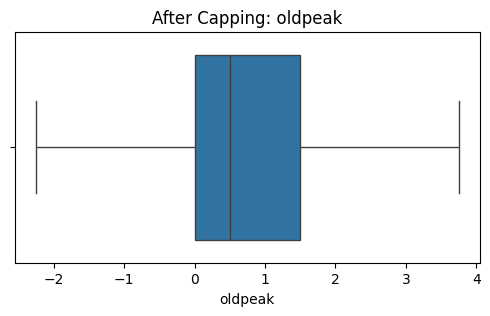

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"After Capping: {col}")
    plt.show()

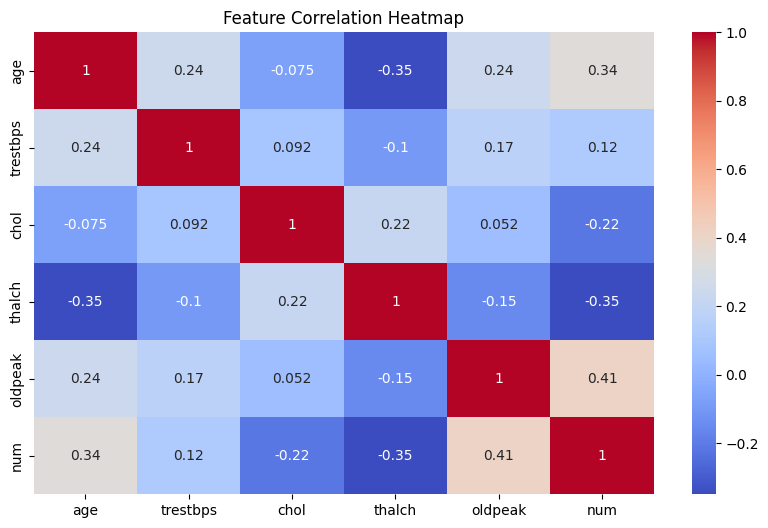

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols + ["num"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [37]:
(df == 0).sum()

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs         780
restecg       0
thalch        0
exang       582
oldpeak     368
num         410
target      410
dtype: int64

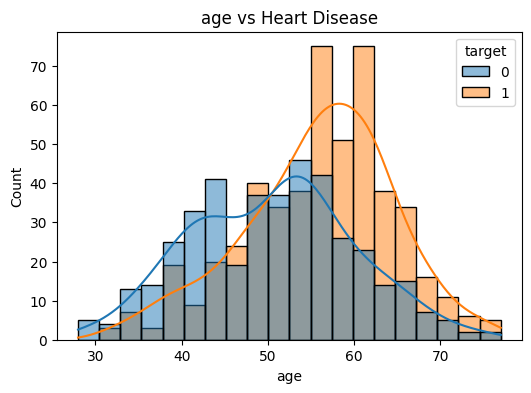

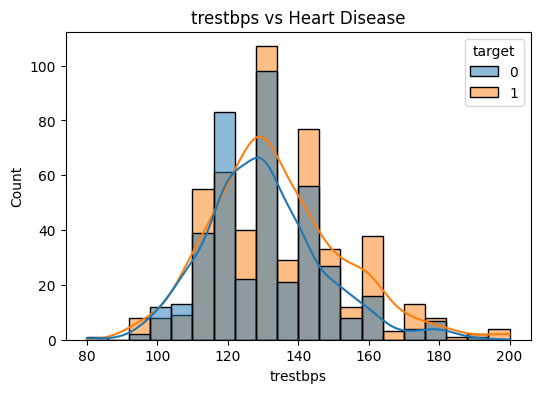

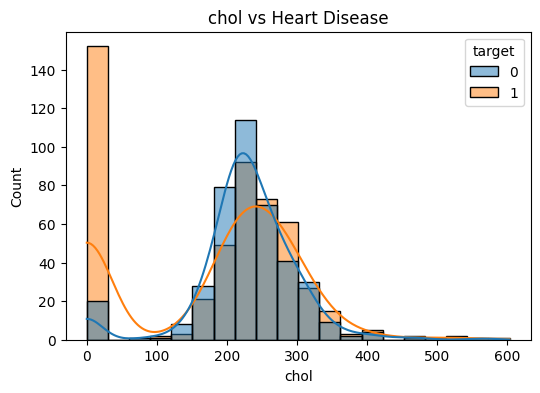

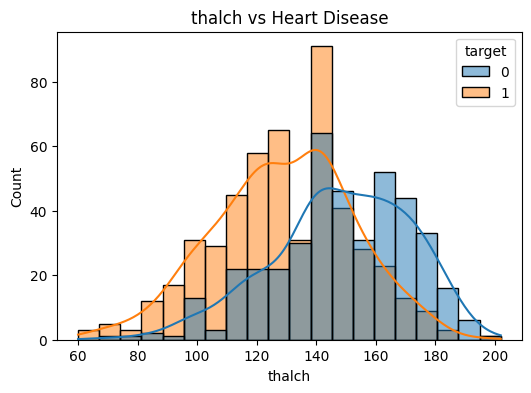

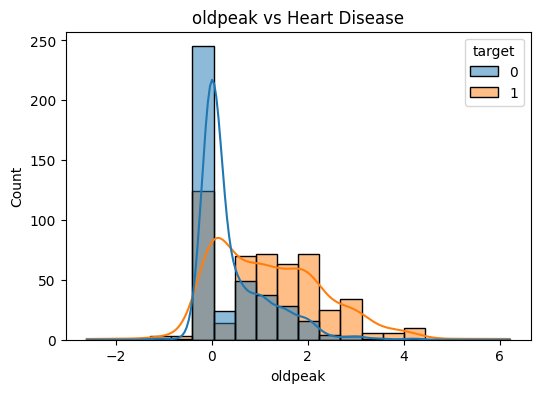

In [31]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="target", kde=True, bins=20)
    plt.title(f"{col} vs Heart Disease")
    plt.show()